The CEPII Gravity dataset is very large and contains many columns of which some are different measures (or sources) of the same variable. We will first load in the dataset, explore the basic structure and subset the data. Loading and using the raw dataset into memory will be inefficient and could introduce co-linearity and redudancy of columns. 

In [289]:
# import packages for simple ingest and setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## The Data

In [290]:
# read in whole dataset NOTE: Is large
df_raw = pd.read_csv('data/Gravity_V202211.csv')

/tmp/ipykernel_213572/1104370669.py:2: DtypeWarning: Columns (0: empire) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv('data/Gravity_V202211.csv')


In [291]:
df_raw[(df_raw['iso3_o'] == 'ABW') & (df_raw['iso3_d'] == 'DEU') & (df_raw['year'] >= 2015) & (df_raw['year'] <= 2019)]

,year,country_id_o,country_id_d,iso3_o,iso3_d,iso3num_o,iso3num_d,country_exists_o,country_exists_d,gmt_offset_2020_o,...,entry_time_o,entry_time_d,entry_tp_o,entry_tp_d,tradeflow_comtrade_o,tradeflow_comtrade_d,tradeflow_baci,manuf_tradeflow_baci,tradeflow_imf_o,tradeflow_imf_d
4359,2015,ABW,DEU.1,ABW,DEU,533.0,280.0,1,0,-4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4360,2016,ABW,DEU.1,ABW,DEU,533.0,280.0,1,0,-4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4361,2017,ABW,DEU.1,ABW,DEU,533.0,280.0,1,0,-4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4362,2018,ABW,DEU.1,ABW,DEU,533.0,280.0,1,0,-4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4363,2019,ABW,DEU.1,ABW,DEU,533.0,280.0,1,0,-4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4433,2015,ABW,DEU.2,ABW,DEU,533.0,276.0,1,1,-4.0,...,NaN,10.5,NaN,19.5,NaN,981.433,880.150,480.840,107.136,935.486
4434,2016,ABW,DEU.2,ABW,DEU,533.0,276.0,1,1,-4.0,...,NaN,10.5,NaN,19.5,NaN,167.238,109.975,22.390,62.032,170.906
4435,2017,ABW,DEU.2,ABW,DEU,533.0,276.0,1,1,-4.0,...,NaN,8.0,NaN,17.0,NaN,58.797,29.371,29.371,124.779,45.939
4436,2018,ABW,DEU.2,ABW,DEU,533.0,276.0,1,1,-4.0,...,NaN,8.0,NaN,17.0,NaN,125.650,82.005,82.005,61.256,116.365
4437,2019,ABW,DEU.2,ABW,DEU,533.0,276.0,1,1,-4.0,...,NaN,8.0,NaN,17.0,NaN,155.079,120.342,120.342,101.471,142.313


we need to take care to drop rows wherecountries don't exist.

In [292]:
# Look at structure of the dataframe
print(f"No of Columns: {len(df_raw.columns)}")
print(f"No of Rows: {len(df_raw)}")
print(df_raw.columns.tolist()[:30])
print(f'Year range: {df_raw['year'].min()} - {df_raw['year'].max()}')
df_raw.head()

No of Columns: 87
No of Rows: 4699296
['year', 'country_id_o', 'country_id_d', 'iso3_o', 'iso3_d', 'iso3num_o', 'iso3num_d', 'country_exists_o', 'country_exists_d', 'gmt_offset_2020_o', 'gmt_offset_2020_d', 'distw_harmonic', 'distw_arithmetic', 'distw_harmonic_jh', 'distw_arithmetic_jh', 'dist', 'main_city_source_o', 'main_city_source_d', 'distcap', 'contig', 'diplo_disagreement', 'scaled_sci_2021', 'comlang_off', 'comlang_ethno', 'comcol', 'col45', 'legal_old_o', 'legal_old_d', 'legal_new_o', 'legal_new_d']
Year range: 1948 - 2021


,year,country_id_o,country_id_d,iso3_o,iso3_d,iso3num_o,iso3num_d,country_exists_o,country_exists_d,gmt_offset_2020_o,...,entry_time_o,entry_time_d,entry_tp_o,entry_tp_d,tradeflow_comtrade_o,tradeflow_comtrade_d,tradeflow_baci,manuf_tradeflow_baci,tradeflow_imf_o,tradeflow_imf_d
0,1948,ABW,ABW,ABW,ABW,533.0,533.0,0,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1949,ABW,ABW,ABW,ABW,533.0,533.0,0,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1950,ABW,ABW,ABW,ABW,533.0,533.0,0,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1951,ABW,ABW,ABW,ABW,533.0,533.0,0,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1952,ABW,ABW,ABW,ABW,533.0,533.0,0,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


We can subset the large dataframe to pick columns which are unique to each type of measure (e.g. only one measure of gdp not 3). 

If we brign in columns like WTO membership (`gatt_o`/`gatt_d`), time zone differences (`tdiff`), and common religion (`comrelig`), we can use our Exploratory Data Analysis (EDA) phase to determine which cultural and diplomatic levers actually impact trade. Variables that prove redundant or statistically insignificant during EDA can be dropped before modeling.

In [293]:
# subset dataframe to 'relevant' columns for EDA
cols_to_use = [
    'year', 'iso3_o', 'iso3_d',        
    'tradeflow_baci',                  
    'gdp_o', 'gdp_d',                  
    'pop_o', 'pop_d',                  
    'distw_harmonic', 'contig',        
    'comlang_off', 'col45',            
    'comrelig', 'diplo_disagreement',  
    'fta_wto',                         
    'wto_o', 'wto_d'     
]

# only bring in countries which exits
df = df_raw[(df_raw['country_exists_o'] ==1) & (df_raw['country_exists_d']==1)]
df = df[cols_to_use].copy()


# subset to a smaller time frame. Most recent and before COVID
df = df[(df['year'] >= 2015) & (df['year'] <= 2019)]
print(f'New dataframe shape: {df.shape}')
df.head(10)

New dataframe shape: (276125, 17)


,year,iso3_o,iso3_d,tradeflow_baci,gdp_o,gdp_d,pop_o,pop_d,distw_harmonic,contig,comlang_off,col45,comrelig,diplo_disagreement,fta_wto,wto_o,wto_d
67,2015,ABW,ABW,NaN,NaN,NaN,104.341,104.341,32.0,0.0,0.0,0.0,0.746,NaN,0.0,0.0,0.0
68,2016,ABW,ABW,NaN,NaN,NaN,104.822,104.822,32.0,0.0,0.0,0.0,0.746,NaN,0.0,0.0,0.0
69,2017,ABW,ABW,NaN,3092178.771,3.092179e+06,105.361,105.361,32.0,0.0,0.0,0.0,0.746,NaN,0.0,0.0,0.0
70,2018,ABW,ABW,NaN,3202234.637,3.202235e+06,105.846,105.846,32.0,0.0,0.0,0.0,0.746,NaN,0.0,0.0,0.0
71,2019,ABW,ABW,NaN,3310055.866,3.310056e+06,106.310,106.310,32.0,0.0,0.0,0.0,0.746,NaN,0.0,0.0,0.0
141,2015,ABW,AFG,NaN,NaN,1.970299e+07,104.341,33736.492,13184.0,0.0,0.0,0.0,0.000,NaN,0.0,0.0,0.0
142,2016,ABW,AFG,NaN,NaN,1.946902e+07,104.822,34656.033,13184.0,0.0,0.0,0.0,0.000,NaN,0.0,0.0,1.0
143,2017,ABW,AFG,160.164,3092178.771,1.875347e+07,105.361,36296.112,13184.0,0.0,0.0,0.0,0.000,NaN,0.0,0.0,1.0
144,2018,ABW,AFG,1023.860,3202234.637,1.805323e+07,105.846,37171.921,13184.0,0.0,0.0,0.0,0.000,NaN,0.0,0.0,1.0
145,2019,ABW,AFG,440.339,3310055.866,1.879945e+07,106.310,38041.756,13184.0,0.0,0.0,0.0,0.000,NaN,0.0,0.0,1.0


In [327]:
# check dtypes
df.dtypes

year                    int64
iso3_o                    str
iso3_d                    str
tradeflow_baci        float64
gdp_o                 float64
gdp_d                 float64
pop_o                 float64
pop_d                 float64
distw_harmonic        float64
contig                float64
comlang_off           float64
col45                 float64
comrelig              float64
diplo_disagreement    float64
fta_wto               float64
wto_o                 float64
wto_d                 float64
dtype: object

In [294]:
# simple describe
df.describe()

,year,tradeflow_baci,gdp_o,gdp_d,pop_o,pop_d,distw_harmonic,contig,comlang_off,col45,comrelig,diplo_disagreement,fta_wto,wto_o,wto_d
count,276125.000000,1.582280e+05,2.307700e+05,2.307700e+05,2.458100e+05,2.458100e+05,276125.000000,276125.00000,253125.000000,253125.000000,204020.000000,185280.000000,276125.000000,276125.000000,276125.000000
mean,2017.000000,5.389042e+05,4.093802e+08,4.093802e+08,3.572281e+04,3.572281e+04,8464.466383,0.01177,0.172760,0.006202,0.178026,0.926075,0.114390,0.691915,0.691915
std,1.414216,5.680852e+06,1.745089e+09,1.745089e+09,1.378519e+05,1.378519e+05,4721.189013,0.10785,0.378041,0.078511,0.253118,0.747763,0.318285,0.461703,0.461703
min,2015.000000,1.000000e-03,3.267328e+04,3.267328e+04,1.057700e+01,1.057700e+01,2.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2016.000000,5.978375e+01,6.678178e+06,6.678178e+06,9.441000e+02,9.441000e+02,4734.000000,0.00000,0.000000,0.000000,0.006000,0.281000,0.000000,0.000000,0.000000
50%,2017.000000,1.783569e+03,2.972770e+07,2.972770e+07,6.965915e+03,6.965915e+03,8088.000000,0.00000,0.000000,0.000000,0.053000,0.743000,0.000000,1.000000,1.000000
75%,2018.000000,3.898187e+04,2.045647e+08,2.045647e+08,2.498269e+04,2.498269e+04,11995.000000,0.00000,0.000000,0.000000,0.249000,1.476000,0.000000,1.000000,1.000000
max,2019.000000,5.009282e+08,2.137257e+10,2.137257e+10,1.407745e+06,1.407745e+06,19904.000000,1.00000,1.000000,1.000000,0.998000,4.720000,1.000000,1.000000,1.000000


In [295]:
# check number of nulls in columns
df.isnull().sum(axis = 0)

year                       0
iso3_o                     0
iso3_d                     0
tradeflow_baci        117897
gdp_o                  45355
gdp_d                  45355
pop_o                  30315
pop_d                  30315
distw_harmonic             0
contig                     0
comlang_off            23000
col45                  23000
comrelig               72105
diplo_disagreement     90845
fta_wto                    0
wto_o                      0
wto_d                      0
dtype: int64

In [296]:
# can we change country codes for actual names for ease of reading?
country_lookup = pd.read_csv('data/Countries_V202211.csv')[['iso3','country']]
country_dict = {k['iso3']: k['country'] for _,k in country_lookup.iterrows()}

#map to existing column (keep iso3 column name for now)
df['iso3_o'] = df['iso3_o'].map(country_dict)
df['iso3_d'] = df['iso3_d'].map(country_dict)

In [297]:
# what rows are they with null gdp?
df[df['gdp_o'].isnull()].head(7)

,year,iso3_o,iso3_d,tradeflow_baci,gdp_o,gdp_d,pop_o,pop_d,distw_harmonic,contig,comlang_off,col45,comrelig,diplo_disagreement,fta_wto,wto_o,wto_d
67,2015,Aruba,Aruba,NaN,NaN,NaN,104.341,104.341,32.0,0.0,0.0,0.0,0.746,NaN,0.0,0.0,0.0
68,2016,Aruba,Aruba,NaN,NaN,NaN,104.822,104.822,32.0,0.0,0.0,0.0,0.746,NaN,0.0,0.0,0.0
141,2015,Aruba,Afghanistan,NaN,NaN,1.970299e+07,104.341,33736.492,13184.0,0.0,0.0,0.0,0.000,NaN,0.0,0.0,0.0
142,2016,Aruba,Afghanistan,NaN,NaN,1.946902e+07,104.822,34656.033,13184.0,0.0,0.0,0.0,0.000,NaN,0.0,0.0,1.0
215,2015,Aruba,Angola,NaN,NaN,1.029622e+08,104.341,27859.304,9572.0,0.0,0.0,0.0,0.607,NaN,0.0,0.0,1.0
216,2016,Aruba,Angola,NaN,NaN,8.963315e+07,104.822,28813.463,9572.0,0.0,0.0,0.0,0.607,NaN,0.0,0.0,1.0
289,2015,Aruba,Anguilla,NaN,NaN,NaN,104.341,NaN,978.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0


### Data Exploration

#### EDA

In [298]:
# what rows are they with null gdp? ..cont
df[df['gdp_o'].isnull()]['iso3_o'].value_counts()

iso3_o
Anguilla                            1175
Bonaire, Sint Eustatius and Saba    1175
Cocos (Keeling) Islands             1175
Cook Islands                        1175
Christmas Island                    1175
Eritrea                             1175
Western Sahara                      1175
Falkland Islands                    1175
Gibraltar                           1175
Guadeloupe                          1175
French Guiana                       1175
British Indian Ocean Territory      1175
Montserrat                          1175
Martinique                          1175
Mayotte                             1175
Norfolk Island                      1175
Niue                                1175
Pitcairn Islands                    1175
North Korea                         1175
Reunion                             1175
Saint Helena                        1175
Saint Pierre and Miquelon           1175
Tokelau                             1175
Holy See                            1175
Venezuela

It looks like a lot ofcountries with 0 gdp are either small countries (albeit still expect GDP) like Kuwait, are dominions of other countries e.g Netherlands Antilles and Greenland, or countries which may not publish gdp (Iran).

In [299]:
# are there countries with 0 trade?
print(f'Rows with 0 trade flow: {len(df[df['tradeflow_baci']== 0])}')
print(f'Rows with nan trade flow: {len(df[df['tradeflow_baci'].isnull()])}')

#not trading with themselves
df[(df['tradeflow_baci'].isnull()) & (df['iso3_o'] != df['iso3_d'])].head()

Rows with 0 trade flow: 0
Rows with nan trade flow: 117897


,year,iso3_o,iso3_d,tradeflow_baci,gdp_o,gdp_d,pop_o,pop_d,distw_harmonic,contig,comlang_off,col45,comrelig,diplo_disagreement,fta_wto,wto_o,wto_d
141,2015,Aruba,Afghanistan,NaN,NaN,1.970299e+07,104.341,33736.492,13184.0,0.0,0.0,0.0,0.000,NaN,0.0,0.0,0.0
142,2016,Aruba,Afghanistan,NaN,NaN,1.946902e+07,104.822,34656.033,13184.0,0.0,0.0,0.0,0.000,NaN,0.0,0.0,1.0
215,2015,Aruba,Angola,NaN,NaN,1.029622e+08,104.341,27859.304,9572.0,0.0,0.0,0.0,0.607,NaN,0.0,0.0,1.0
216,2016,Aruba,Angola,NaN,NaN,8.963315e+07,104.822,28813.463,9572.0,0.0,0.0,0.0,0.607,NaN,0.0,0.0,1.0
217,2017,Aruba,Angola,NaN,3092178.771,6.897276e+07,105.361,29816.769,9572.0,0.0,0.0,0.0,0.607,NaN,0.0,0.0,1.0


A head and tail of the dataframe with NaN in the tradeflow column show that it is likely that there is 0 trade between these countries. This is also corroborated by the fact that there is no row with '0' as a value of trade.

In [300]:
# what countries have no pop?
df[df['pop_o'].isnull()]['iso3_o'].value_counts()

iso3_o
Anguilla                            1175
Bonaire, Sint Eustatius and Saba    1175
Cocos (Keeling) Islands             1175
Cook Islands                        1175
Christmas Island                    1175
Eritrea                             1175
Western Sahara                      1175
Falkland Islands                    1175
Guadeloupe                          1175
French Guiana                       1175
British Indian Ocean Territory      1175
Montserrat                          1175
Martinique                          1175
Mayotte                             1175
Norfolk Island                      1175
Niue                                1175
Pitcairn Islands                    1175
Reunion                             1175
Saint Helena                        1175
Saint Pierre and Miquelon           1175
Tokelau                             1175
Holy See                            1175
Wallis and Futuna                   1175
Congo, Democratic Rep. of the        470
Gibraltar

In [301]:
df[df['iso3_o'] == 'Germany'].head()

,year,iso3_o,iso3_d,tradeflow_baci,gdp_o,gdp_d,pop_o,pop_d,distw_harmonic,contig,comlang_off,col45,comrelig,diplo_disagreement,fta_wto,wto_o,wto_d
1100299,2015,Germany,Aruba,10527.454,3.363600e+09,NaN,81686.607,104.341,8239.0,0.0,0.0,0.0,0.338,NaN,1.0,1.0,0.0
1100300,2016,Germany,Aruba,11305.574,3.466757e+09,NaN,82667.686,104.822,8239.0,0.0,0.0,0.0,0.338,NaN,1.0,1.0,0.0
1100301,2017,Germany,Aruba,10468.788,3.690849e+09,3092178.771,82657.005,105.361,8239.0,0.0,0.0,0.0,0.338,NaN,1.0,1.0,0.0
1100302,2018,Germany,Aruba,53889.145,3.977289e+09,3202234.637,82905.785,105.846,8239.0,0.0,0.0,0.0,0.338,NaN,1.0,1.0,0.0
1100303,2019,Germany,Aruba,10174.652,3.888327e+09,3310055.866,83092.964,106.310,8239.0,0.0,0.0,0.0,0.338,NaN,1.0,1.0,0.0


In [302]:
df[df['iso3_o'] == 'Germany'].tail(10)

,year,iso3_o,iso3_d,tradeflow_baci,gdp_o,gdp_d,pop_o,pop_d,distw_harmonic,contig,comlang_off,col45,comrelig,diplo_disagreement,fta_wto,wto_o,wto_d
1118799,2015,Germany,Zambia,78941.252,3.363600e+09,2.115439e+07,81686.607,16100.588,7514.0,0.0,0.0,0.0,0.24,1.791,0.0,1.0,1.0
1118800,2016,Germany,Zambia,71528.232,3.466757e+09,1.955109e+07,82667.686,16591.391,7514.0,0.0,0.0,0.0,0.24,1.888,0.0,1.0,1.0
1118801,2017,Germany,Zambia,75120.249,3.690849e+09,2.587360e+07,82657.005,16853.607,7514.0,0.0,0.0,0.0,0.24,1.914,0.0,1.0,1.0
1118802,2018,Germany,Zambia,91352.667,3.977289e+09,2.631159e+07,82905.785,17351.713,7514.0,0.0,0.0,0.0,0.24,1.907,0.0,1.0,1.0
1118803,2019,Germany,Zambia,87050.127,3.888327e+09,2.330867e+07,83092.964,17861.034,7514.0,0.0,0.0,0.0,0.24,1.746,0.0,1.0,1.0
1118873,2015,Germany,Zimbabwe,55954.178,3.363600e+09,1.607238e+07,81686.607,15777.451,7984.0,0.0,0.0,0.0,0.15,2.824,0.0,1.0,1.0
1118874,2016,Germany,Zimbabwe,35862.124,3.466757e+09,1.628921e+07,82667.686,16150.362,7984.0,0.0,0.0,0.0,0.15,2.871,0.0,1.0,1.0
1118875,2017,Germany,Zimbabwe,36396.363,3.690849e+09,1.758489e+07,82657.005,14236.599,7984.0,0.0,0.0,0.0,0.15,3.180,0.0,1.0,1.0
1118876,2018,Germany,Zimbabwe,42785.492,3.977289e+09,1.811554e+07,82905.785,14438.812,7984.0,0.0,0.0,0.0,0.15,2.698,0.0,1.0,1.0
1118877,2019,Germany,Zimbabwe,47487.737,3.888327e+09,1.928429e+07,83092.964,14645.473,7984.0,0.0,0.0,0.0,0.15,1.622,1.0,1.0,1.0


In [343]:
df.columns

Index(['year', 'iso3_o', 'iso3_d', 'tradeflow_baci', 'gdp_o', 'gdp_d', 'pop_o',
       'pop_d', 'distw_harmonic', 'contig', 'comlang_off', 'col45', 'comrelig',
       'diplo_disagreement', 'fta_wto', 'wto_o', 'wto_d'],
      dtype='str')

In [ ]:
# which countries have null common languages?
df[df['comlang_off'].isnull()]['iso3_o'].value_counts()

iso3_o
American Samoa                      1175
Bonaire, Sint Eustatius and Saba    1175
Curacao                             1175
Guam                                1175
British Indian Ocean Territory      1175
                                    ... 
Samoa                                 50
Yemen                                 50
South Africa                          50
Zambia                                50
Zimbabwe                              50
Name: count, Length: 235, dtype: int64

In [349]:
df[df['comlang_off'].isnull()].sort_values(['iso3_o', 'year'], ascending = True)

,year,iso3_o,iso3_d,tradeflow_baci,gdp_o,gdp_d,pop_o,pop_d,distw_harmonic,contig,comlang_off,col45,comrelig,diplo_disagreement,fta_wto,wto_o,wto_d
19529,2015,Afghanistan,American Samoa,NaN,1.970299e+07,641000.000,33736.492,55.537,13750.0,0.0,NaN,NaN,0.000,NaN,0.0,0.0,0.0
20121,2015,Afghanistan,"Bonaire, Sint Eustatius and Saba",NaN,1.970299e+07,NaN,33736.492,NaN,13095.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0
22563,2015,Afghanistan,Curacao,NaN,1.970299e+07,NaN,33736.492,157.979,13145.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0
25671,2015,Afghanistan,Guam,NaN,1.970299e+07,5734000.128,33736.492,161.797,7961.0,0.0,NaN,NaN,0.000,NaN,0.0,0.0,0.0
26411,2015,Afghanistan,British Indian Ocean Territory,NaN,1.970299e+07,NaN,33736.492,NaN,4637.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4690117,2019,Zimbabwe,Liechtenstein,NaN,1.928429e+07,6427248.943,14645.473,38.020,7561.0,0.0,NaN,NaN,0.149,1.142,0.0,1.0,1.0
4690709,2019,Zimbabwe,Monaco,NaN,1.928429e+07,7383745.662,14645.473,38.967,7275.0,0.0,NaN,NaN,0.140,1.454,0.0,1.0,0.0
4692263,2019,Zimbabwe,Mayotte,NaN,1.928429e+07,NaN,14645.473,NaN,1696.0,0.0,NaN,NaN,0.011,NaN,0.0,1.0,0.0
4696407,2019,Zimbabwe,Sint Marteen,NaN,1.928429e+07,NaN,14645.473,41.608,10987.0,0.0,NaN,NaN,0.145,NaN,0.0,1.0,0.0


In [ ]:
# if we drop null in common lang what countries will be inpacted most
df[df['comlang_off'].isnull()].groupby(['year', 'iso3_o']).count().reset_index()[['year','iso3_o','iso3_d','tradeflow_baci']].sort_values('tradeflow_baci', ascending = False)

# looks like smaller countries may not give a language value

,year,iso3_o,iso3_d,tradeflow_baci
55,2015,Curacao,235,111
525,2017,Curacao,235,102
290,2016,Curacao,235,102
995,2019,Curacao,235,100
760,2018,Curacao,235,97
...,...,...,...,...
696,2017,Uzbekistan,10,0
697,2017,Vanuatu,10,0
698,2017,Venezuela,10,0
678,2017,Tanzania,10,0


In [ ]:
# if we drop null in common lang what countries will be inpacted most
df[df['comrelig'].isnull()].groupby(['year', 'iso3_o']).count().reset_index()[['year','iso3_o','iso3_d','tradeflow_baci']].sort_values('tradeflow_baci', ascending = False).head(20)

# looks like smaller countries again may not give a religion value

,year,iso3_o,iso3_d,tradeflow_baci
355,2016,Lithuania,235,197
590,2017,Lithuania,235,195
825,2018,Lithuania,235,194
1060,2019,Lithuania,235,193
120,2015,Lithuania,235,189
892,2018,Serbia,235,180
1127,2019,Serbia,235,176
657,2017,Serbia,235,174
422,2016,Serbia,235,174
187,2015,Serbia,235,168


In [360]:
df.isnull().sum(axis=0)

year                       0
iso3_o                     0
iso3_d                     0
tradeflow_baci        117897
gdp_o                  45355
gdp_d                  45355
pop_o                  30315
pop_d                  30315
distw_harmonic             0
contig                     0
comlang_off            23000
col45                  23000
comrelig               72105
diplo_disagreement     90845
fta_wto                    0
wto_o                      0
wto_d                      0
dtype: int64

Most nulls on columns come from smaller nations, and as a result can be dropped, since they would have less GPD/tradeflow/pop and thus less important to our outcome. 

## Distribution Exploration

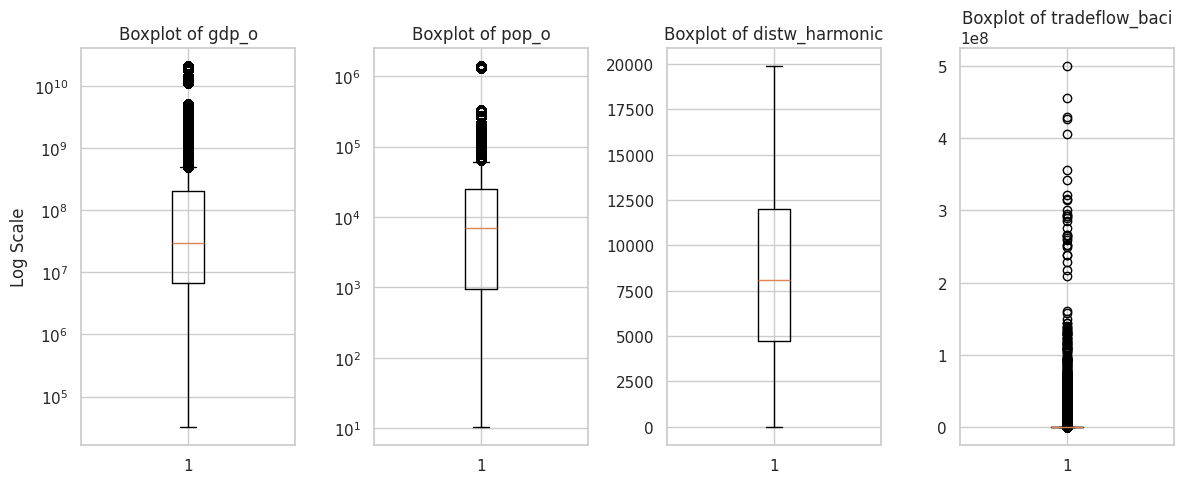

In [313]:
# Plotting boxplots for each variable to see distribution and also check for outliers
fig, axs = plt.subplots(1, 4, figsize=(12, 5))

axs[0].boxplot(df['gdp_o'].dropna())
axs[0].set_title("Boxplot of gdp_o")
axs[0].set_yscale('log') # This stops outliers from squashing the box!
axs[0].set_ylabel("Log Scale")

# Plot 2: Population (Dropping NaNs and using log scale)
axs[1].boxplot(df['pop_o'].dropna())
axs[1].set_title("Boxplot of pop_o")
axs[1].set_yscale('log')

# Plot 3: Distance (Dropping NaNs)
axs[2].boxplot(df['distw_harmonic'].dropna())
axs[2].set_title("Boxplot of distw_harmonic")

# Plot 4: Let's look at Log Trade instead of fta_wto
# (Since fta_wto is just 1s and 0s, it breaks the boxplot logic)
axs[3].boxplot(df['tradeflow_baci'].dropna())
axs[3].set_title("Boxplot of tradeflow_baci")

plt.tight_layout()
plt.show()



Text(0.5, 1.0, 'Boxplot of Tradflow by Trade Agreement')

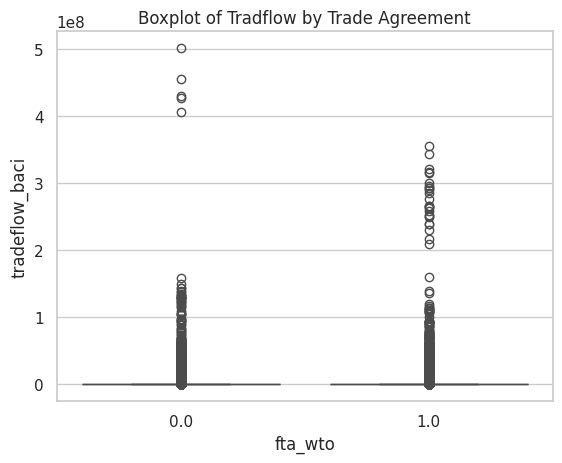

In [314]:
# does having a trade agreement look different?
sns.boxplot(x = 'fta_wto', y='tradeflow_baci', data=df)

# Adding title
plt.title('Boxplot of Tradflow by Trade Agreement')

Text(0.5, 1.0, 'Boxplot of Tradeflow by Common Language')

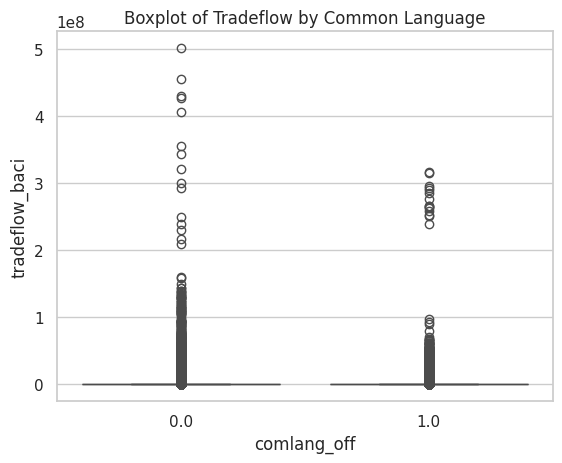

In [315]:
# does having a common language look different?
sns.boxplot(x = 'comlang_off', y='tradeflow_baci', data=df)

# Adding title
plt.title('Boxplot of Tradeflow by Common Language')

Text(0.5, 1.0, 'Scatterplot of Tradeflow by Common Religion')

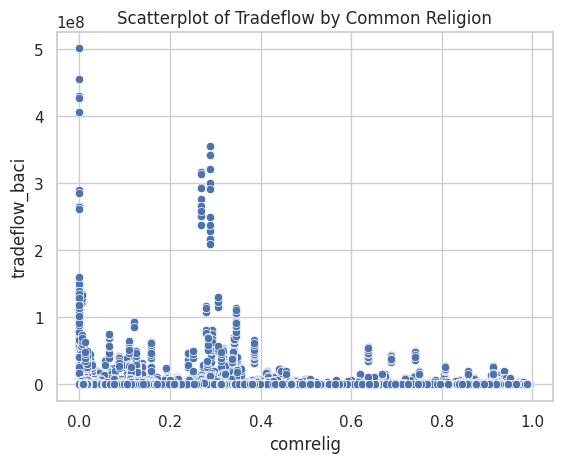

In [316]:
# does having a religion look different?
sns.scatterplot(x = 'comrelig', y='tradeflow_baci', data=df)

# Adding title
plt.title('Scatterplot of Tradeflow by Common Religion')

Text(0.5, 1.0, 'Scatterplot of Tradeflow by Distance')

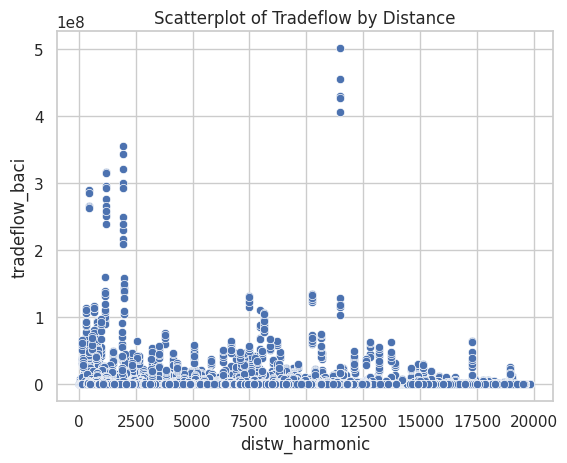

In [317]:
# does distance look different?
sns.scatterplot(x = 'distw_harmonic', y='tradeflow_baci', data=df)

# Adding title
plt.title('Scatterplot of Tradeflow by Distance')

In [318]:
df.columns

Index(['year', 'iso3_o', 'iso3_d', 'tradeflow_baci', 'gdp_o', 'gdp_d', 'pop_o',
       'pop_d', 'distw_harmonic', 'contig', 'comlang_off', 'col45', 'comrelig',
       'diplo_disagreement', 'fta_wto', 'wto_o', 'wto_d'],
      dtype='str')

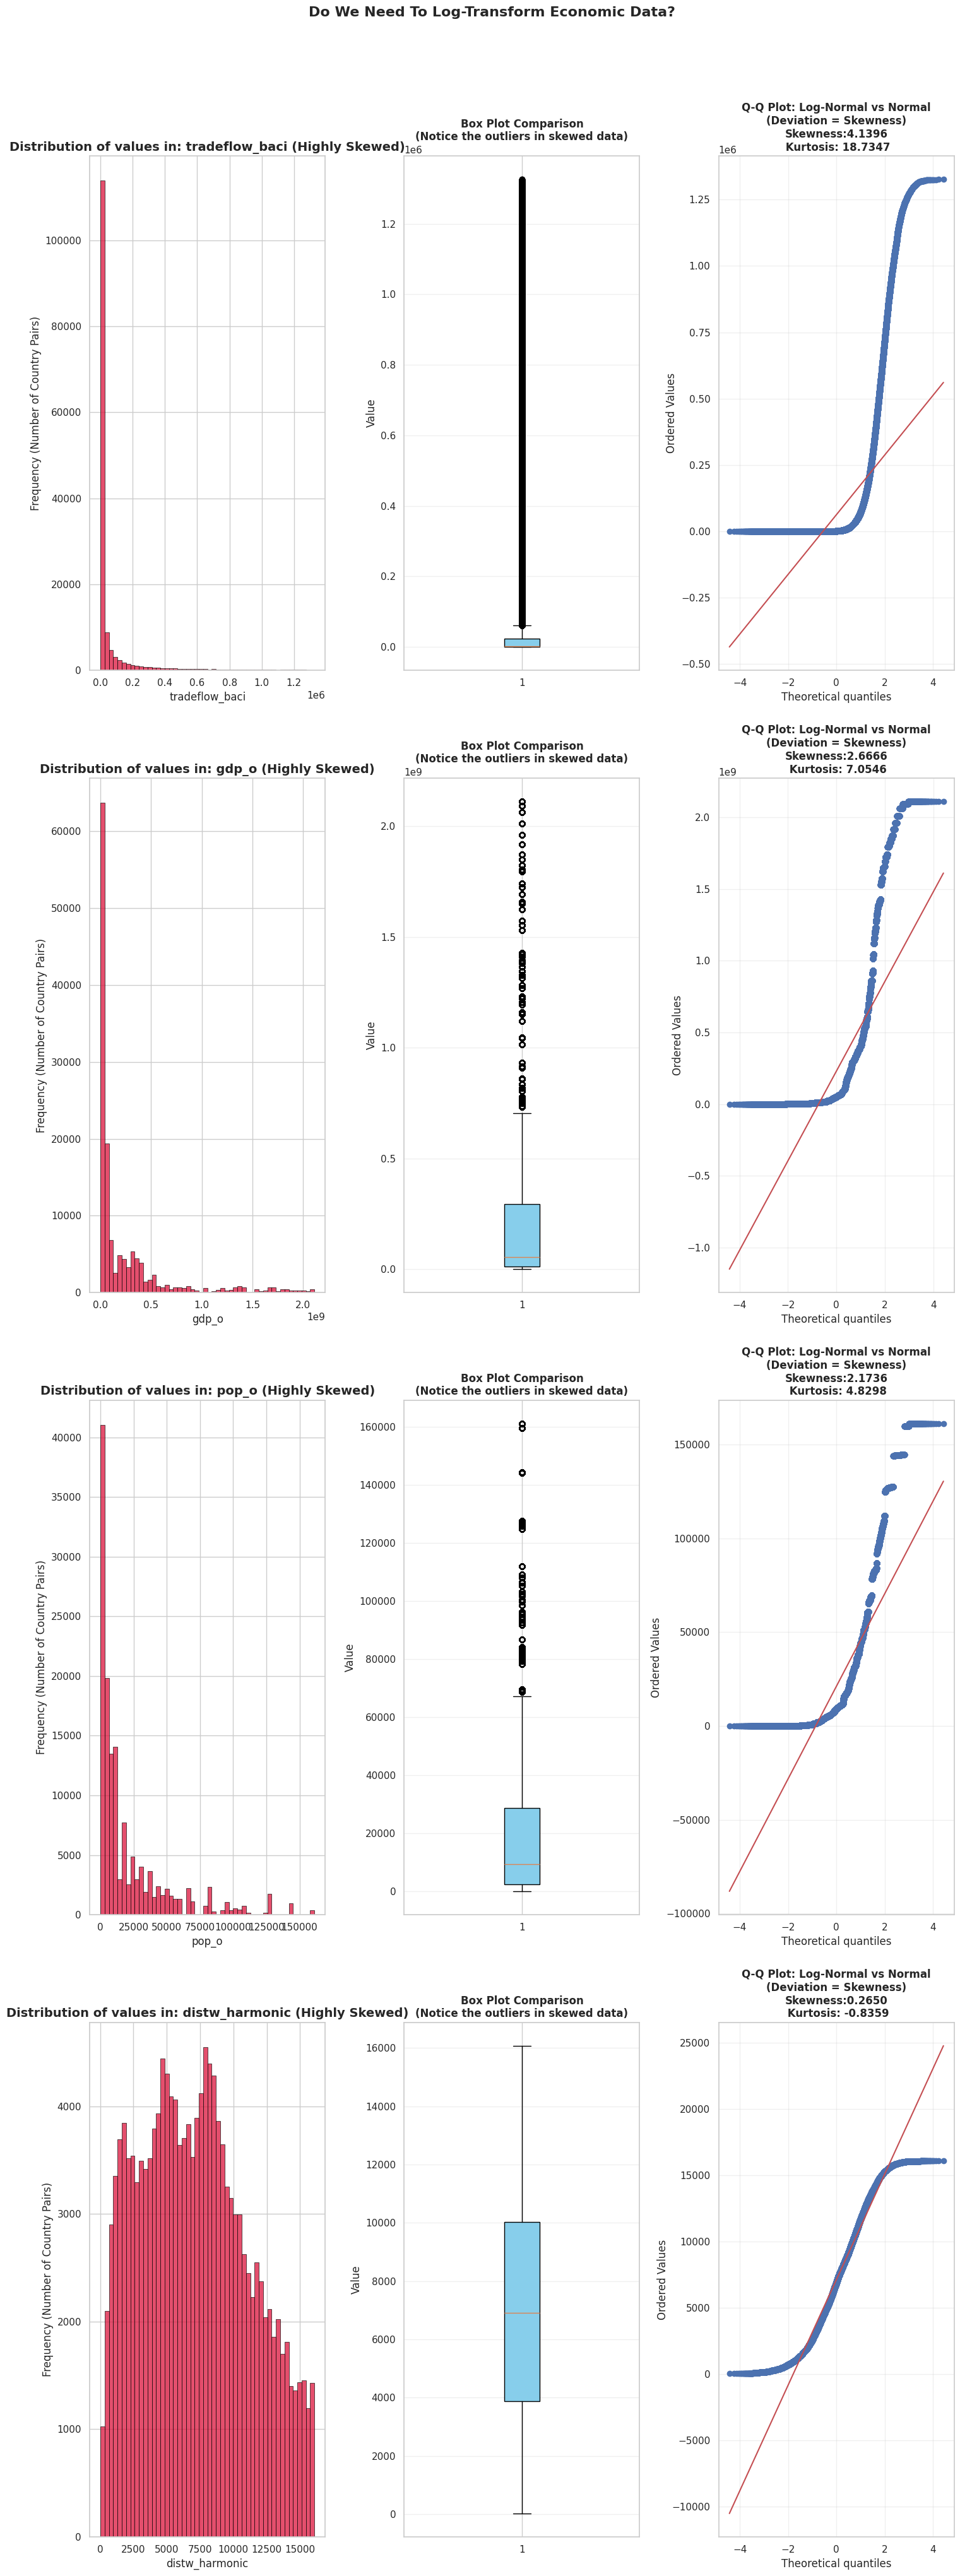

In [319]:
sns.set_theme(style="whitegrid")

# check few numeric columns
cols_to_check = [
    'tradeflow_baci', 'gdp_o', 'pop_o',
    'distw_harmonic', 
]


# create a X by 3 plot fig
fig, axes = plt.subplots(len(cols_to_check), 3,figsize=(15, 40))

for i, col in enumerate(cols_to_check):
    
    # remove 95% perctentile because of high kurtosis plots look useless
    positive_trade = df[df['tradeflow_baci'] > 0][col]
    cutoff_95 = positive_trade.quantile(0.95)
    zoomed_raw_trade = positive_trade[positive_trade < cutoff_95]

    sns.histplot(zoomed_raw_trade, bins=50, ax=axes[i, 0], color='crimson', edgecolor='black')
    axes[i,0].set_title(f'Distribution of values in: {col} (Highly Skewed)', fontsize=14, fontweight = 'bold')
    axes[i, 0].set_xlabel(f'{col}', fontsize=12)
    axes[i, 0].set_ylabel(f'Frequency (Number of Country Pairs)', fontsize=12)

    #Box Plot Comparison - showing skewness visually
    ax5 = axes[i, 1]
    data_to_compare = zoomed_raw_trade
    bp = ax5.boxplot(data_to_compare, patch_artist=True) 
    colors = ['skyblue', 'coral', 'lightgreen']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    ax5.set_ylabel('Value')
    ax5.set_title('Box Plot Comparison\n(Notice the outliers in skewed data)', fontweight='bold')
    ax5.grid(alpha=0.3, axis='y')

    #Quantile-Quantile (Q-Q) Plot: Normal vs Log-Normal
    ax6 = axes[i, 2]
    from scipy import stats
    stats.probplot(zoomed_raw_trade, dist="norm", plot=ax6) 
    ax6.set_title(f'Q-Q Plot: Log-Normal vs Normal\n(Deviation = Skewness)\nSkewness:{stats.skew(zoomed_raw_trade):.4f}\n Kurtosis: {stats.kurtosis(zoomed_raw_trade):.4f}', fontweight='bold')
    ax6.grid(alpha=0.3)

# --- Plot 2: Log-Transformed Trade Flows (The "After") ---

# Add an overall title
plt.suptitle('Do We Need To Log-Transform Economic Data?', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

The Above plots show that there is a lot of skewness and kurtosis aswell as outliers in our dataset. We will need to transform these for future use.

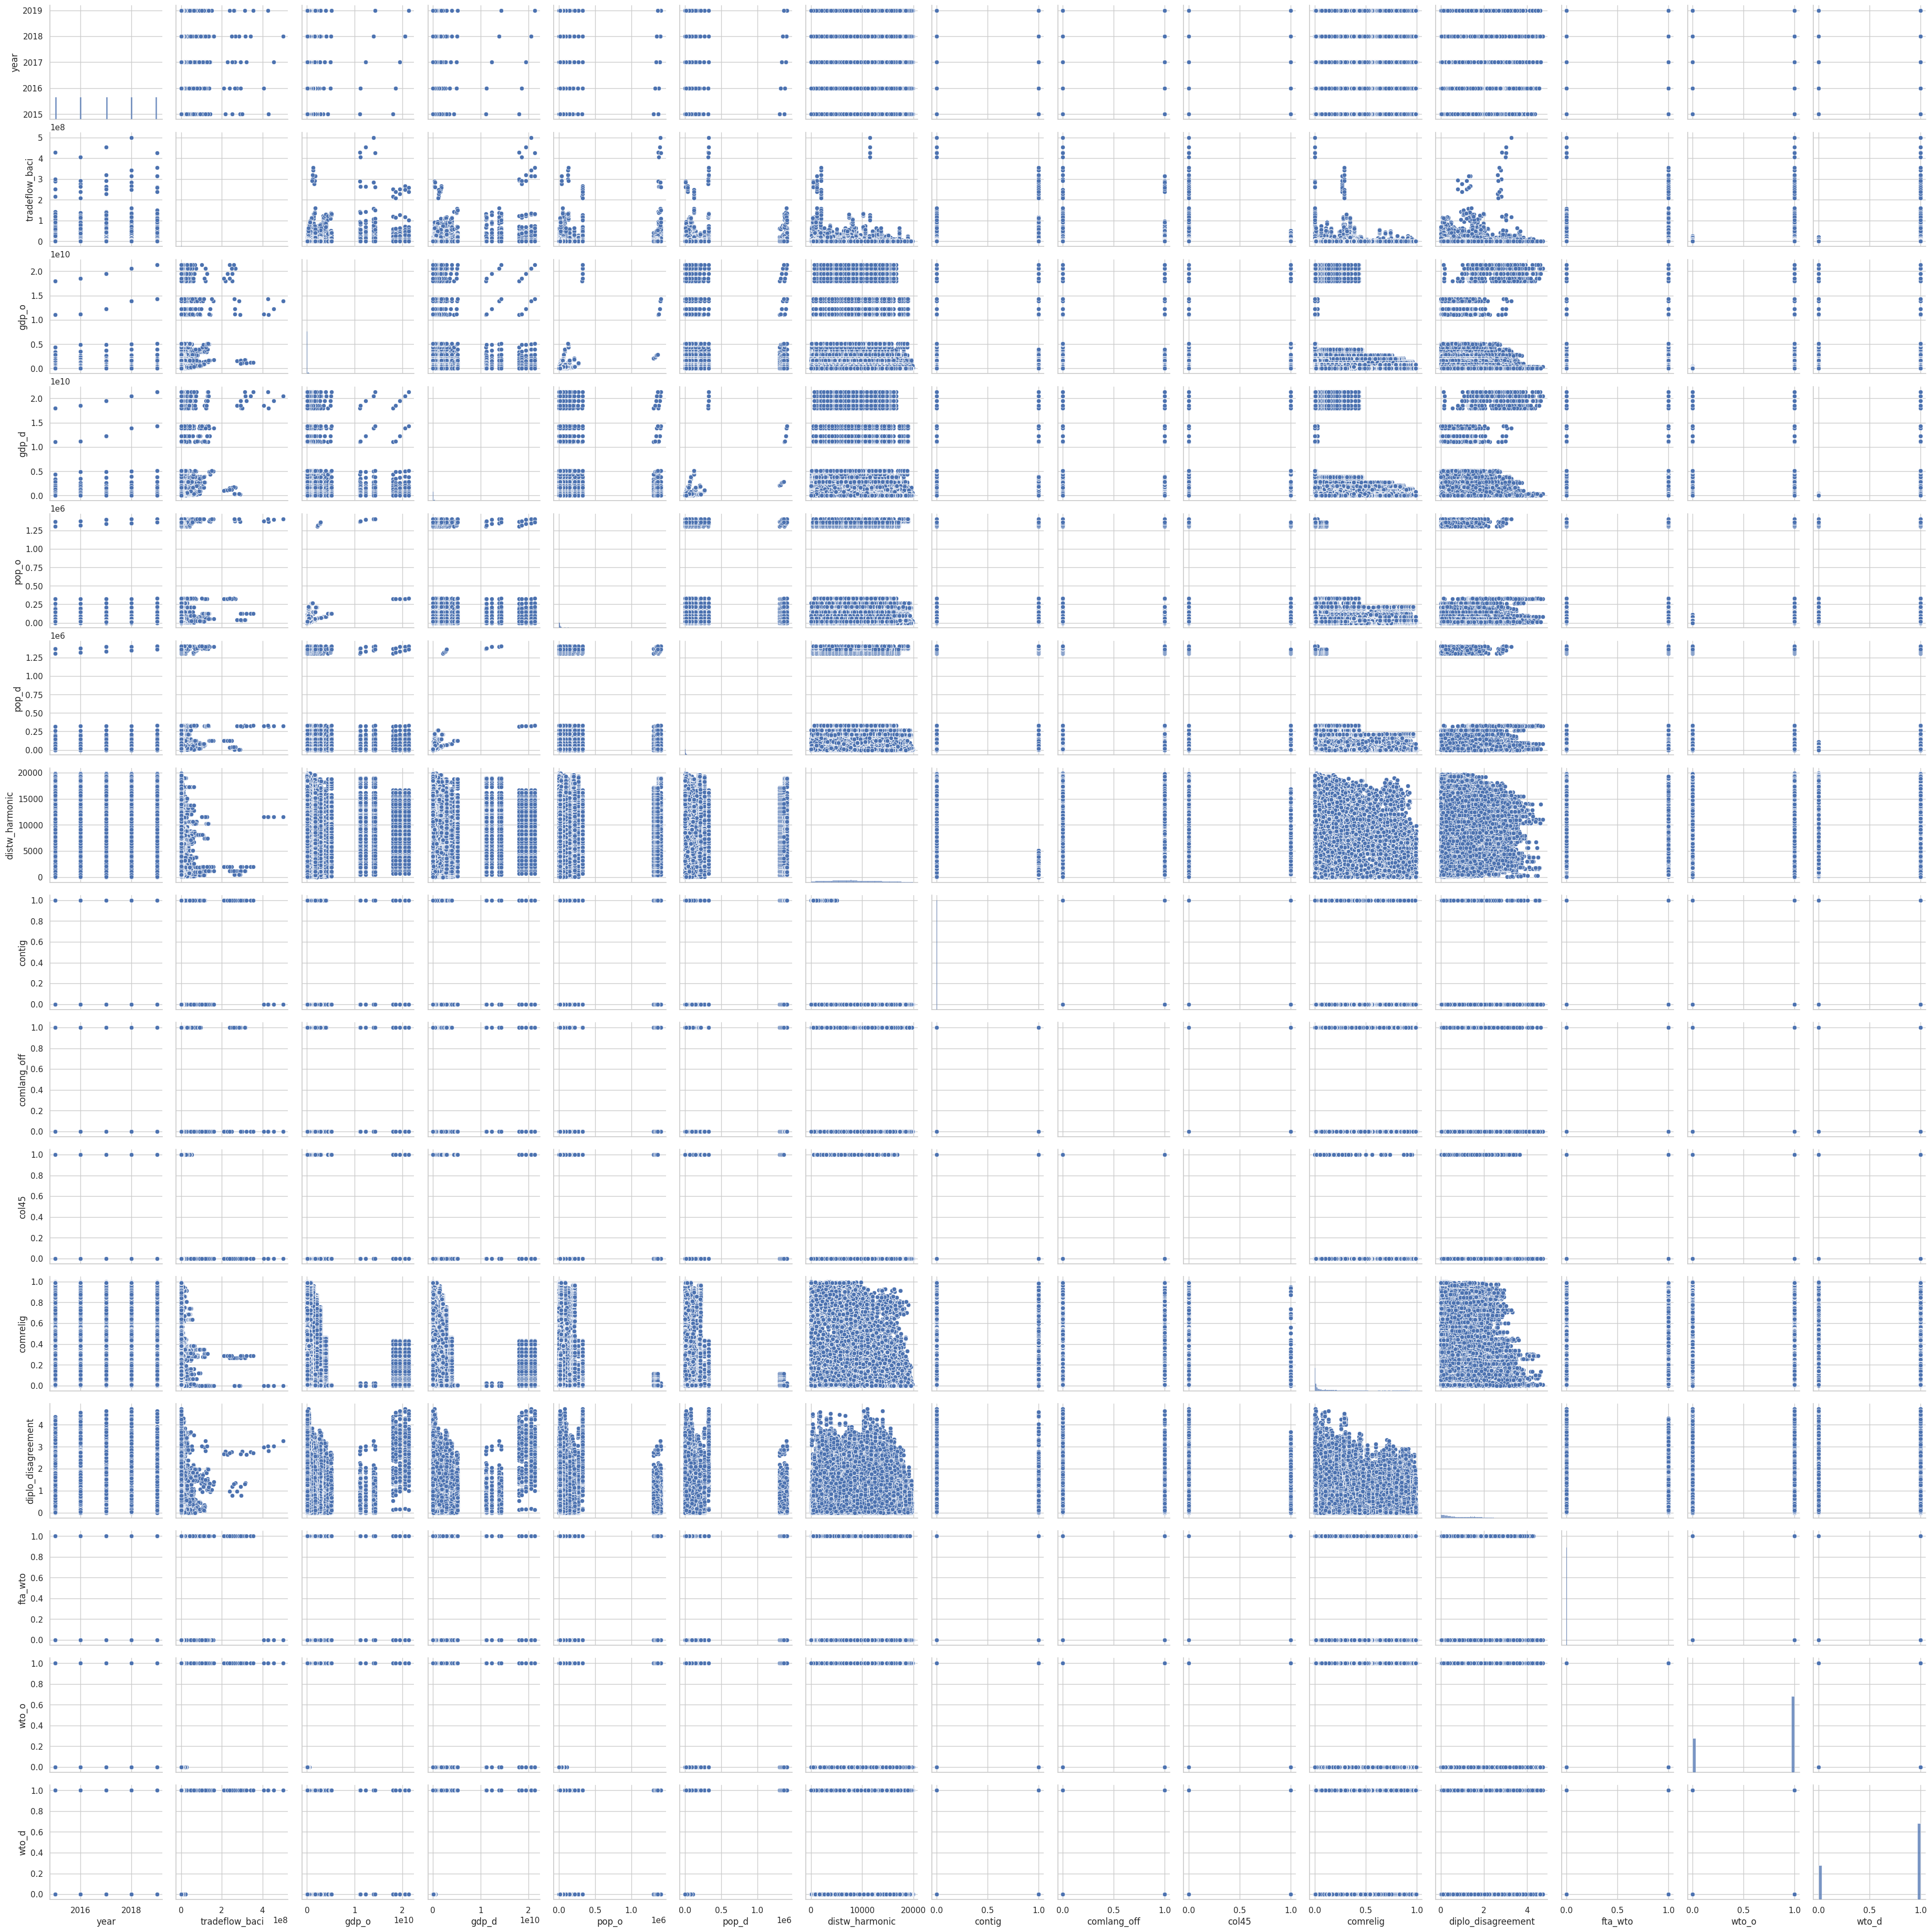

In [ ]:
# runs long (10mins)
#sns.pairplot(df)

In [362]:
df.shape

(276125, 17)

TODO: log last

## Model Traning and Evaluation